In [22]:
import os

# Create screenshots folder if it doesn't exist
screenshots_path = r'C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\dashboard\screenshots'
os.makedirs(screenshots_path, exist_ok=True)
print(f"Folder ready: {screenshots_path}")

Folder ready: C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\dashboard\screenshots


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed dataset
df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\data\processed\zomato_with_refunds.csv')

print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

Shape: (45584, 24)

Data Types:
ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weather_conditions                 str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries            float64
Festival                           str
City                               str
Time_taken (min)                 int64
Customer_ID                        str
Refund_Requested                  bool
Refund_Reason                      str
Refund_Amount                  float64
dtype: object

Missing Values:
I

In [24]:
# Fix 1: Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

# Fix 2: Convert Age to integer (after handling NaN)
df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(
    df['Delivery_person_Age'].median()
).astype(int)

# Fix 3: Convert multiple_deliveries to integer
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0).astype(int)

# Verify fixes
print(df[['Order_Date', 'Delivery_person_Age', 'multiple_deliveries']].dtypes)
print(f"\nSample dates: {df['Order_Date'].head(3).tolist()}")
print(f"Sample ages: {df['Delivery_person_Age'].head(3).tolist()}")

Order_Date             datetime64[us]
Delivery_person_Age             int64
multiple_deliveries             int64
dtype: object

Sample dates: [Timestamp('2022-02-12 00:00:00'), Timestamp('2022-02-13 00:00:00'), Timestamp('2022-03-04 00:00:00')]
Sample ages: [36, 21, 23]


In [25]:
# Overall refund rate
total_orders = len(df)
total_refunds = df['Refund_Requested'].sum()
refund_rate = df['Refund_Requested'].mean() * 100

print(f"Total Orders: {total_orders:,}")
print(f"Total Refund Requests: {total_refunds:,}")
print(f"Overall Refund Rate: {refund_rate:.2f}%")
print(f"Total Refund Amount: ₹{df['Refund_Amount'].sum():,.2f}")

# Refund breakdown by reason
print("\nRefund Requests by Reason:")
print(df['Refund_Reason'].value_counts())

# Refund rate by city
print("\nRefund Rate by City:")
city_refund = df.groupby('City')['Refund_Requested'].agg(['sum','mean','count'])
city_refund.columns = ['Total_Refunds', 'Refund_Rate', 'Total_Orders']
city_refund['Refund_Rate'] = (city_refund['Refund_Rate'] * 100).round(2)
city_refund = city_refund.sort_values('Refund_Rate', ascending=False)
print(city_refund)

Total Orders: 45,584
Total Refund Requests: 3,596
Overall Refund Rate: 7.89%
Total Refund Amount: ₹974,343.55

Refund Requests by Reason:
Refund_Reason
Wrong Item           862
Item Not Received    594
Missing Item         550
Late Delivery        550
Damaged Packaging    535
Poor Quality         505
Name: count, dtype: int64

Refund Rate by City:
               Total_Refunds  Refund_Rate  Total_Orders
City                                                   
Metropolitian           2699         7.92         34087
Urban                    773         7.63         10133
Semi-Urban                12         7.32           164


C:\Users\user\AppData\Local\Temp\ipykernel_7372\3755236639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.values,


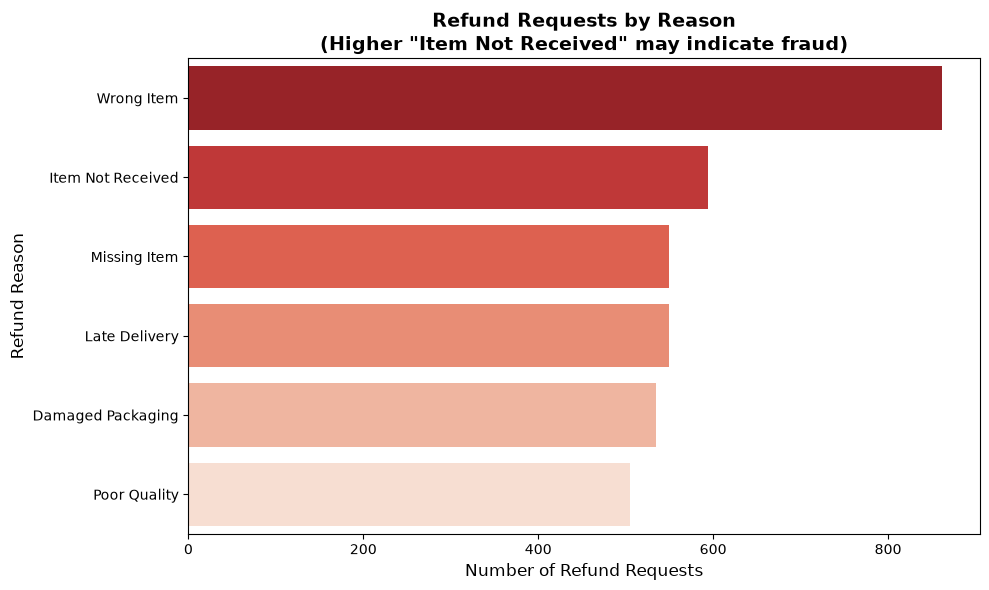

Chart saved successfully!


In [26]:
plt.figure(figsize=(10, 6))

# Count refund reasons
reason_counts = df['Refund_Reason'].value_counts()

# Create bar chart
sns.barplot(x=reason_counts.values, 
            y=reason_counts.index, 
            palette='Reds_r')

# Professional formatting
plt.title('Refund Requests by Reason\n(Higher "Item Not Received" may indicate fraud)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Refund Requests', fontsize=12)
plt.ylabel('Refund Reason', fontsize=12)
plt.tight_layout()

# Save for dashboard screenshots folder
plt.savefig(r'C:\Users\user\OneDrive\Desktop\zomato-refund-fraud-analytics\dashboard\screenshots\refund_by_reason.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved successfully!")